**Cohort analysis**

Cohort analysis involves dividing users into distinct groups, or cohorts, based on certain criteria. In this case study, these cohorts are defined by the time of user acquisition. By grouping users together based on time of acquisition, we can study how different cohorts behave in terms of engagement and retention.

For example, you might create cohorts based on the month users first signed up for your service. You can then track how each cohort's activity, such as their conversion rate or lifetime value, evolves over time. This approach allows you to identify trends, anomalies, and areas where you may need to make adjustments to improve user retention and satisfaction.

**Retention Rate Time-Based Cohort Analysis:**

Retention rate time-based cohort analysis is a specialized form of cohort analysis that focuses on the retention of users over multiple time periods.

To perform retention rate time-based cohort analysis, you would typically:

- Create cohorts based on user acquisition dates.

- Measure the percentage of users from each cohort who continue to engage with your product or service over time (e.g., after 1 month, 3 months, etc.).

- Analyze how retention rates vary across different cohorts and time periods, enabling you to identify trends and make data-driven decisions.

This analysis can reveal whether certain cohorts have better or worse retention rates, helping the business understand the factors contributing to user retention or attrition. It can also assist in optimizing marketing, product development, and customer support strategies.

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime as dt
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Load and prepare dataset

In [2]:
# Load daatset

data = pd.read_csv("../data/Dataset_ecommerce.csv")
data

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,536365,2010-12-01 08:26:00,17850.0,SC1734,Electronics,65,10.23,Egypt
1,536365,2010-12-01 08:26:00,17850.0,SC2088,Furniture,95,19.61,Mali
2,536365,2010-12-01 08:26:00,17850.0,SC3463,Books,78,61.49,Mali
3,536365,2010-12-01 08:26:00,17850.0,SC6228,Toys,15,24.73,South Africa
4,536365,2010-12-01 08:26:00,17850.0,SC2149,Toys,50,38.83,Rwanda
...,...,...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,SC5440,Furniture,25,36.53,Mozambique
541905,581587,2011-12-09 12:50:00,12680.0,SC3576,Cloths,94,90.65,Tunisia
541906,581587,2011-12-09 12:50:00,12680.0,SC5283,Furniture,14,40.07,Somalia
541907,581587,2011-12-09 12:50:00,12680.0,SC1099,Cosmetics,45,79.83,Senegal


In [3]:
data.describe(include ="all")

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
count,541909,541909,406829.000000,541909,541909,541909.000000,541909.000000,541909
unique,25900,23260,NaN,9000,10,NaN,NaN,28
top,573585,2011-10-31 14:41:00,NaN,SC2014,Sports Equipment,NaN,NaN,Cote d'Ivoire
freq,1114,1114,NaN,96,54765,NaN,NaN,19651
mean,NaN,NaN,15287.690570,NaN,NaN,50.534748,50.476354,NaN
std,NaN,NaN,1713.600303,NaN,NaN,28.849367,28.564775,NaN
min,NaN,NaN,12346.000000,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,13953.000000,NaN,NaN,26.000000,25.750000,NaN
50%,NaN,NaN,15152.000000,NaN,NaN,51.000000,50.430000,NaN
75%,NaN,NaN,16791.000000,NaN,NaN,76.000000,75.180000,NaN


## Data Preprocessing and Cleaning

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   InvoiceDate  541909 non-null  object 
 2   CustomerID   406829 non-null  float64
 3   StockCode    541909 non-null  object 
 4   Description  541909 non-null  object 
 5   Quantity     541909 non-null  int64  
 6   UnitPrice    541909 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
data.isnull().sum()

InvoiceNo           0
InvoiceDate         0
CustomerID     135080
StockCode           0
Description         0
Quantity            0
UnitPrice           0
Country             0
dtype: int64

In [6]:
# Drop missing columm
data.dropna(inplace = True)

#we can only track the activities of customers that are known (those with customerID)

In [7]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# Exploratory data analysis

## Analysis by country

**Bivariate analysis of countries and total number of purchase**

In [8]:
quantity_per_country = data.groupby(["Country"])["Quantity"].sum().reset_index()
quantity_per_country = quantity_per_country.sort_values("Quantity", ascending = False).reset_index()

In [9]:
quantity_per_country.head(3)

,index,Country,Quantity
0,23,Togo,741223
1,20,South Africa,740589
2,4,Cote d'Ivoire,740229


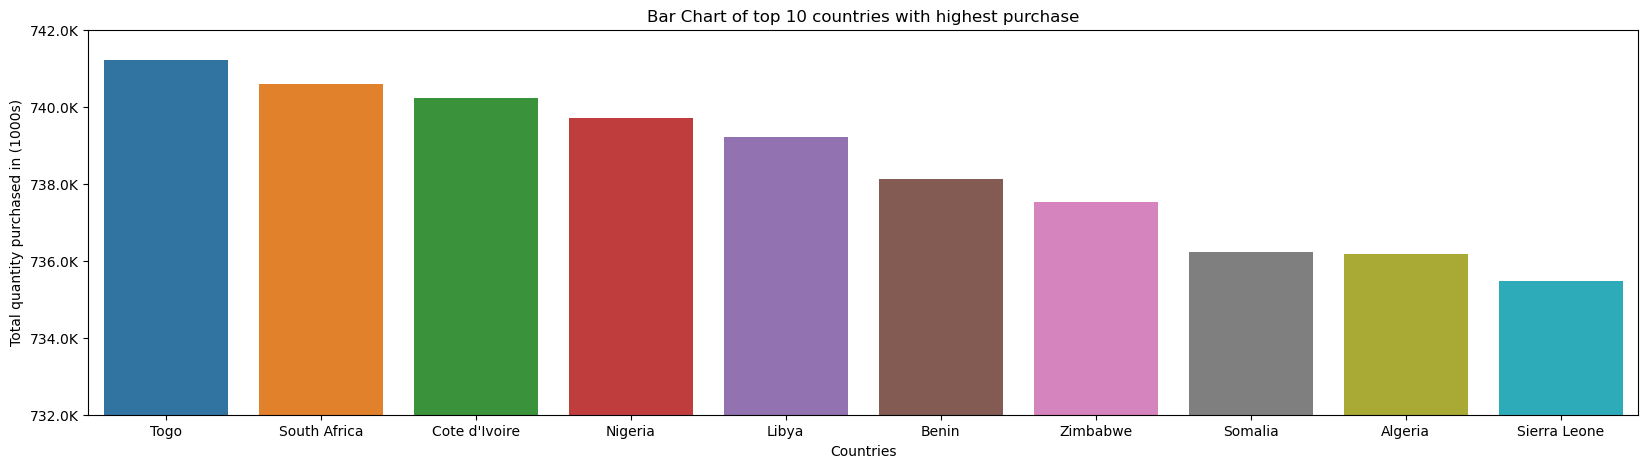

In [10]:
# Draw a plot of top 10 countries with highest number of quantity purchase
top_10_countries = quantity_per_country.head(10)

# Create a bar chart from the selected data
plt.figure(figsize=(20, 5))

y_format = FuncFormatter(lambda x, _: f'{x / 1000:.1f}K')
ax = sns.barplot(x='Country', y='Quantity', data= top_10_countries)
ax.yaxis.set_major_formatter(y_format)

plt.xlabel('Countries')
plt.ylabel('Total quantity purchased in (1000s)')
plt.title('Bar Chart of top 10 countries with highest purchase')
plt.ylim(7.32e5, 7.42e5)

plt.show()

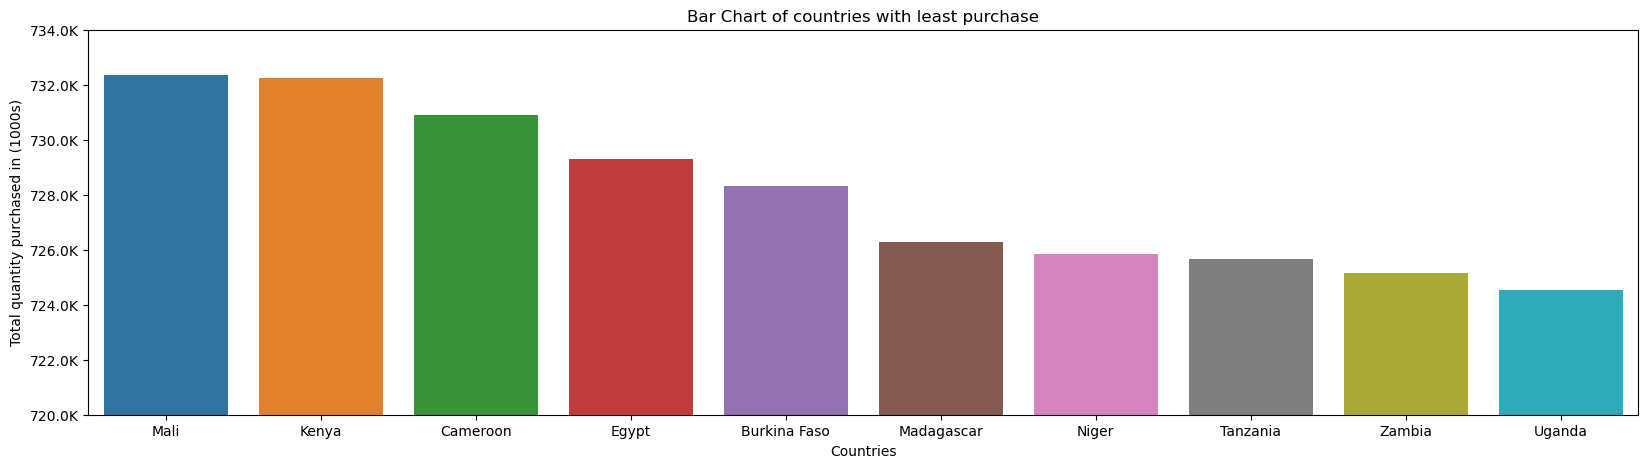

In [11]:
# Draw a plot of 10 countries with least number of quantity purchase
least_10_countries = quantity_per_country.tail(10)

# Create a bar chart from the selected data
plt.figure(figsize=(20, 5))

y_format = FuncFormatter(lambda x, _: f'{x / 1000:.1f}K')
ax = sns.barplot(x='Country', y='Quantity', data= least_10_countries)
ax.yaxis.set_major_formatter(y_format)

plt.xlabel('Countries')
plt.ylabel('Total quantity purchased in (1000s)')
plt.title('Bar Chart of countries with least purchase')
plt.ylim(7.20e5, 7.34e5)

plt.show()

**Bivariate analysis of countries and number of customers**

In [12]:
country_to_customers = data.groupby(["Country"])["CustomerID"].nunique().reset_index()
country_to_customers = country_to_customers.sort_values("CustomerID", ascending = False).reset_index()
country_to_customers.rename(columns = {"CustomerID" : "Number of customers"}, inplace = True)

In [13]:
country_to_customers.head(3)

,index,Country,Number of customers
0,13,Mozambique,3072
1,1,Benin,3054
2,23,Togo,3053


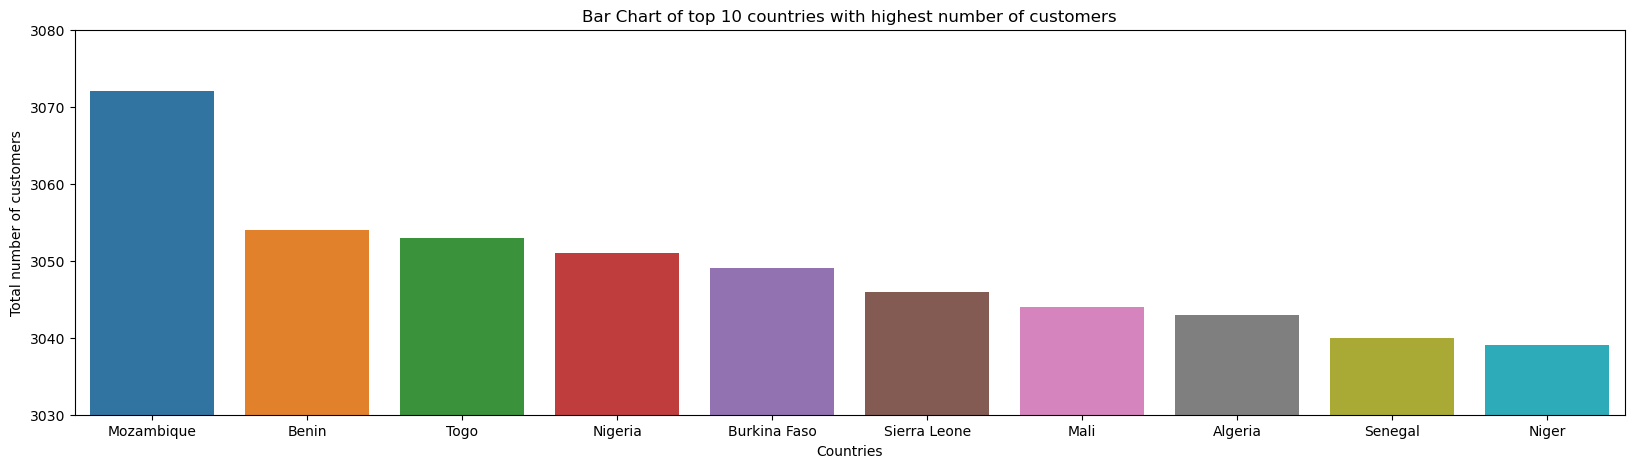

In [14]:
# Draw a plot of top 10 countries with highest number of customers (unique customerID)
top_countries_to_customers = country_to_customers.head(10)

# Create a bar chart from the selected data
plt.figure(figsize=(20, 5))

sns.barplot(x='Country', y='Number of customers', data= top_countries_to_customers)

plt.xlabel('Countries')
plt.ylabel('Total number of customers')
plt.title('Bar Chart of top 10 countries with highest number of customers')
plt.ylim(3030, 3080)

plt.show()

## Sales trend

In [15]:
# Group the data by month and calculate the total monthly sales
monthly_sales = data.groupby(data['InvoiceDate'].dt.to_period('M'))['Quantity'].sum()

# Create folder one level up
output_dir = os.path.join(os.path.dirname(os.getcwd()), 'visualizations')
os.makedirs(output_dir, exist_ok=True)

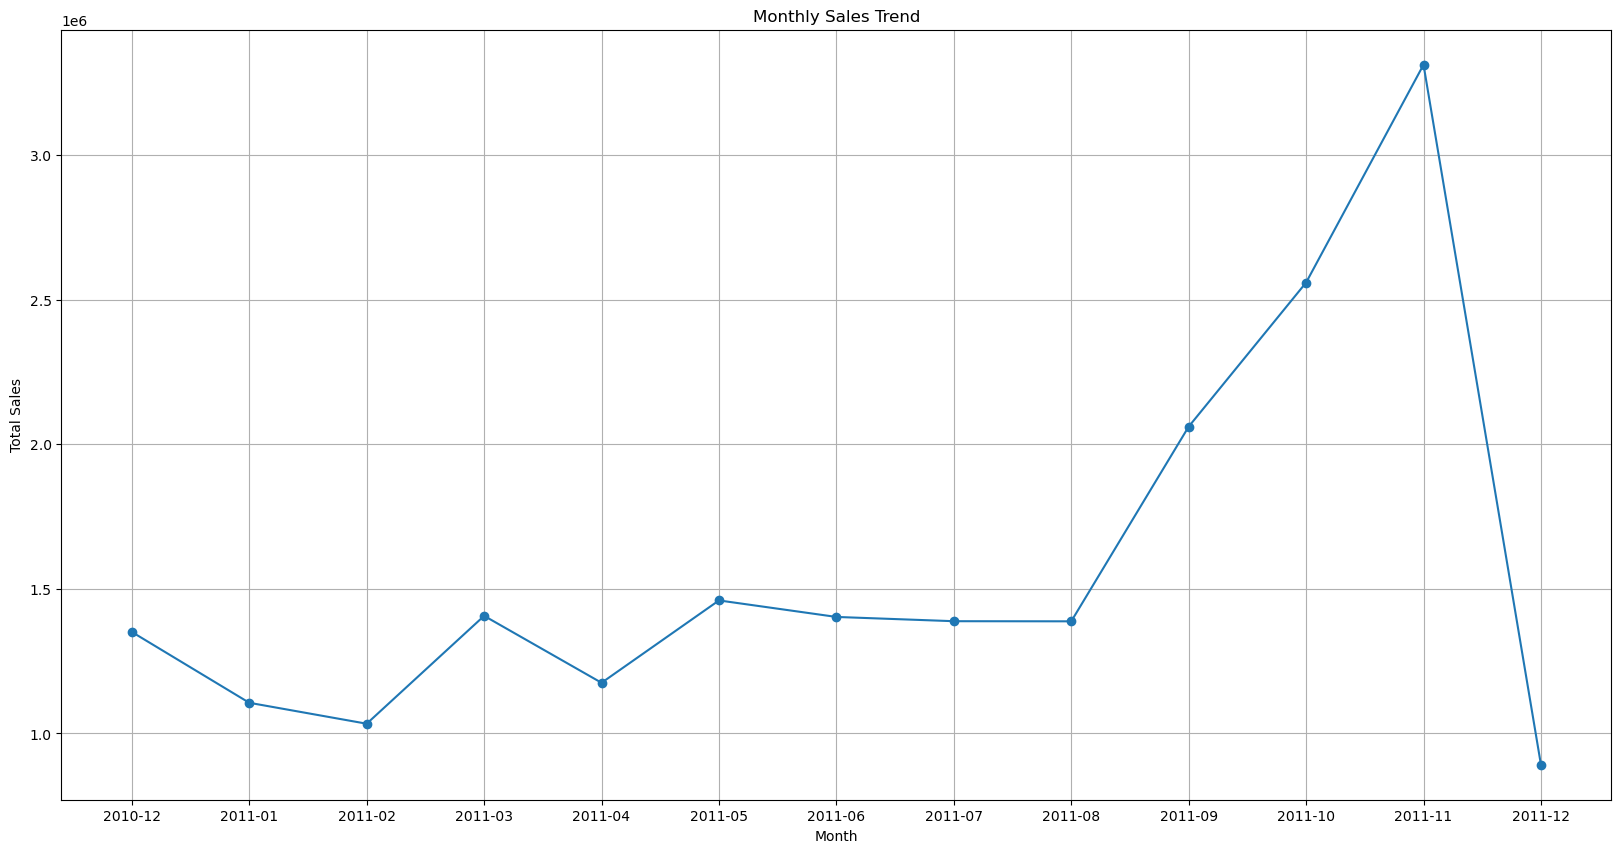

In [16]:
# Create a line chart
plt.figure(figsize=(20, 10))
plt.plot(monthly_sales.index.strftime('%Y-%m'), monthly_sales.values, marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.grid(True)

# Save as PNG
output_path = os.path.join(output_dir, 'monthly_sales_trend.png')
plt.savefig(output_path)

# Display the plot
plt.show()


## **Sales Trend Observations**

- **Initial Dip:** Sales declined from December 2010 to February 2011, hitting a low in February.
- **Moderate Recovery:** Slight growth in March and May, followed by a flat trend from June to August 2011.
- *December 2010 to August 2011: Noticeable fluctuations in sales quantity.*
- **Strong Growth:** A significant sales sharp increase from August to November 2011, with November being the peak month.
- **Sharp Drop:** Sales experienced a significant decline in December, likely due to seasonal closure or end of data collection.

## Top Selling Products

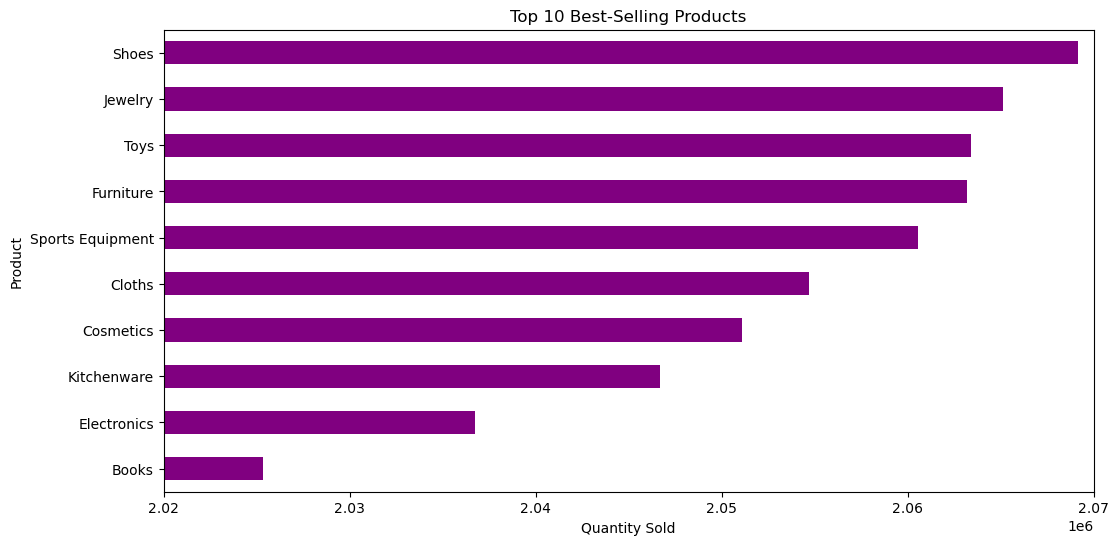

In [17]:
# Top Selling Products
# Total quantity sold per product
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=True).head(10)

# Create folder one level up if it doesn't exist
output_dir = os.path.join(os.path.dirname(os.getcwd()), 'visualizations')
os.makedirs(output_dir, exist_ok=True)

# PLot
plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='purple')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.xlim(2.02e6, 2.07e6)

# Save the figure as PNG
output_path = os.path.join(output_dir, 'top_10_best_selling_products.png')
plt.savefig(output_path)

# Display the plot
plt.show()


## Top 10 Best-Selling Products - Key Insights

- The bar chart displays the **Top 10 products by total quantity sold**, with all categories nearing **2 million units.**
- **Shoes** led slightly, followed closely by **Jewelry, Toys, Furniture**, and others.
- The near-uniform performance suggests a **well-diversified product portfolio** and **balanced consumer demand.**
- Such distribution reduces reliance on a single product and rreflects **effective inventory and marketing strategies**
- This balance enhances **business resilience** and supports consistent performance across **seasonal or market shifts.**

## Customer Activity

In [18]:
data['CustomerID'].nunique(), data['InvoiceNo'].nunique()

(4372, 22190)

In [19]:
data.groupby('CustomerID')['InvoiceNo'].nunique().max()

248

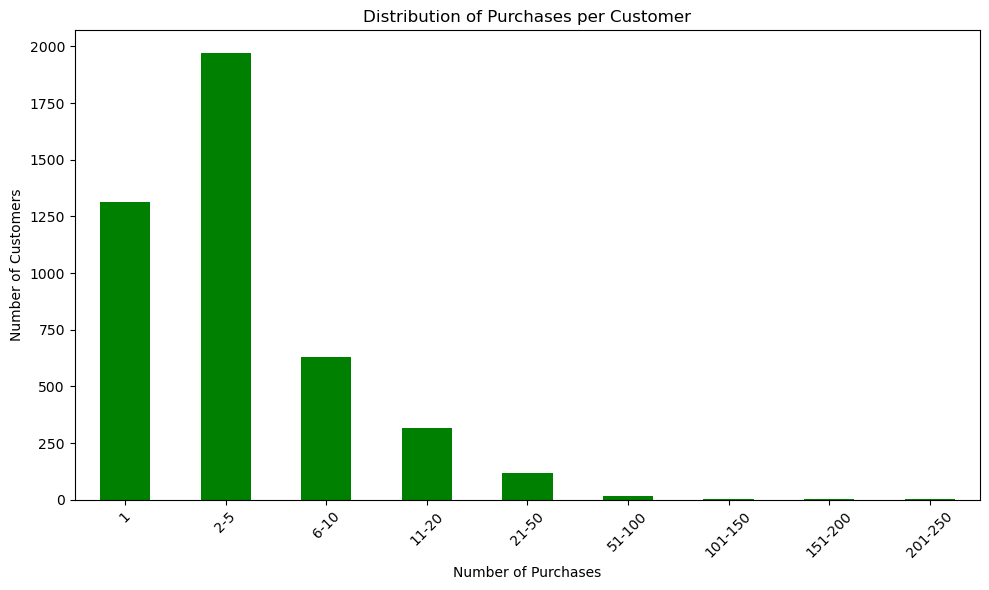

In [20]:
# Count unique purchases per customer
customer_purchases = data.groupby('CustomerID')['InvoiceNo'].nunique()

# Create folder one level up if it doesn't exist
output_dir = os.path.join(os.path.dirname(os.getcwd()), 'visualizations')
os.makedirs(output_dir, exist_ok=True)

# Bin the number of purchases into ranges
bins = [0, 1, 5, 10, 20, 50, 100, 150, 200, 250]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-150', '151-200', '201-250']
binned = pd.cut(customer_purchases, bins=bins, labels=labels, include_lowest=True)

# Count number of customers in each bin
purchase_distribution = binned.value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
purchase_distribution.plot(kind='bar', color='green')
plt.title('Distribution of Purchases per Customer')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure as PNG
output_path = os.path.join(output_dir, 'distribution_of_purchases_per_customer.png')
plt.savefig(output_path)

# Display the plot
plt.show()


# Cohort Analysis

## What is Cohort Analysis

Cohort analysis is a way to track groups of users over time. A cohort is a group of customers who share a common starting point; for example, customers who made their first purchase in the same month. 

By analyzing these groups separately, we can understand:

- How well we retain customers

- How customer behavior changes over time

- How valuable each cohort is.

In [21]:
data['TotalPrice'] = data['UnitPrice']
data['CohortMonth'] = data.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')

### We determine the first month a customer made a purchase (this becomes their CohortMonth)

We also extract the month of every invoice (InvoiceMonth).

This helps us calculate how many months have passed since each customer's first purchase.


In [22]:
from operator import attrgetter

cohorts = data.groupby(['CohortMonth', 'InvoiceMonth'])['CustomerID'].nunique().reset_index()
cohorts['CohortIndex'] = (cohorts['InvoiceMonth'] - cohorts['CohortMonth']).apply(attrgetter('n'))

### We count how many unique customers purchased in each InvoiceMonth within each CohortMonth.

Then we calculate how many months have passed since the first purchase. This is called CohortIndex.

In [23]:
cohort_pivot = cohorts.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

### We pivot the table so:

- Rows = Each cohort's starting month
- Columns = How many months since they joined
- Values = Number of customers active in that month

We divide each row by its cohort size to get retention rate per month.

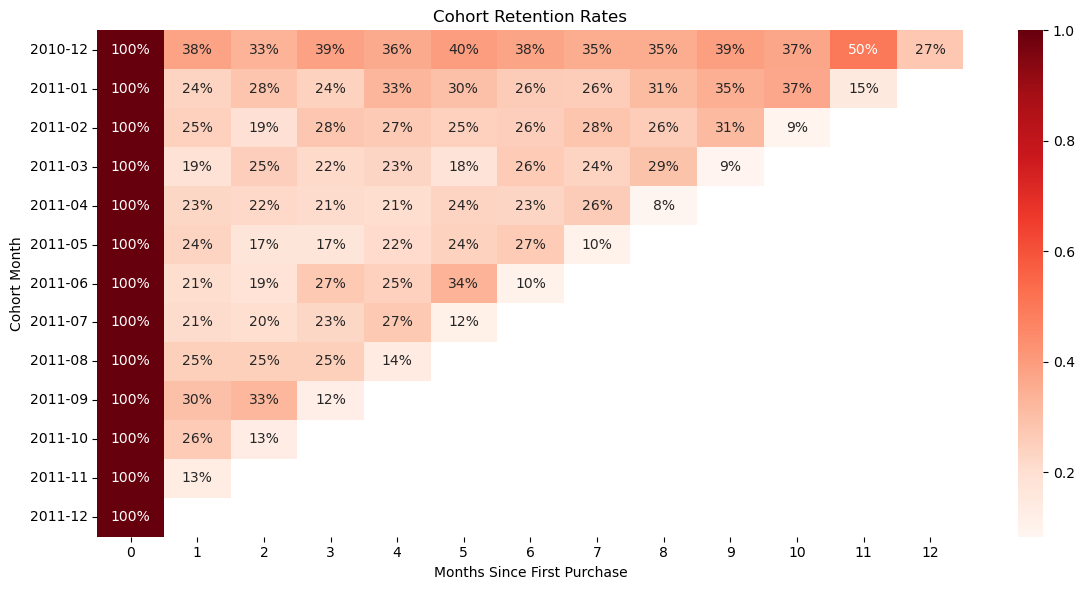

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Reds')
plt.title('Cohort Retention Rates')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

## Cohort Retention Matrix - Key Insights

### Insights:

- **Early Drop**: Most cohorts drop from 100% to 13-38% in Month 1; strong early churn.
- **Stabilization**: Retention levels off after Month 3, indicating loyal customer base.

### Best Cohort: 2010-12

- Retains **50% by Month 11**, ends at **27% in Month 12.**
- Suggests effective holiday acquisition or onboarding.

### Weak Cohorts:

- **2011-11:** Only 13% in Month 1.
- **2011-04:** Falls to 8% by Month 7; fast drop-off.

### Takeaways:

- Replicate 2010-12 strategies.
- Improve onboarding to reduce Month 1 churn.
- Audit acquisition sources for low retention cohorts.


## Cohort Lifetime Value (CLV)

In [25]:
cohort_revenue = data.groupby(['CohortMonth', 'InvoiceMonth'])['TotalPrice'].sum().reset_index()
cohort_revenue['CohortIndex'] = (cohort_revenue['InvoiceMonth'] - cohort_revenue['CohortMonth']).apply(attrgetter('n'))
cohort_cumrev = cohort_revenue.pivot(index='CohortMonth', columns='CohortIndex', values='TotalPrice').cumsum(axis=1)

### We calculate total revenue per cohort per month.

Then we compute the cumulative revenue for each cohort (aka cohort CLV).

The plot shows how valuable each cohort becomes over time.

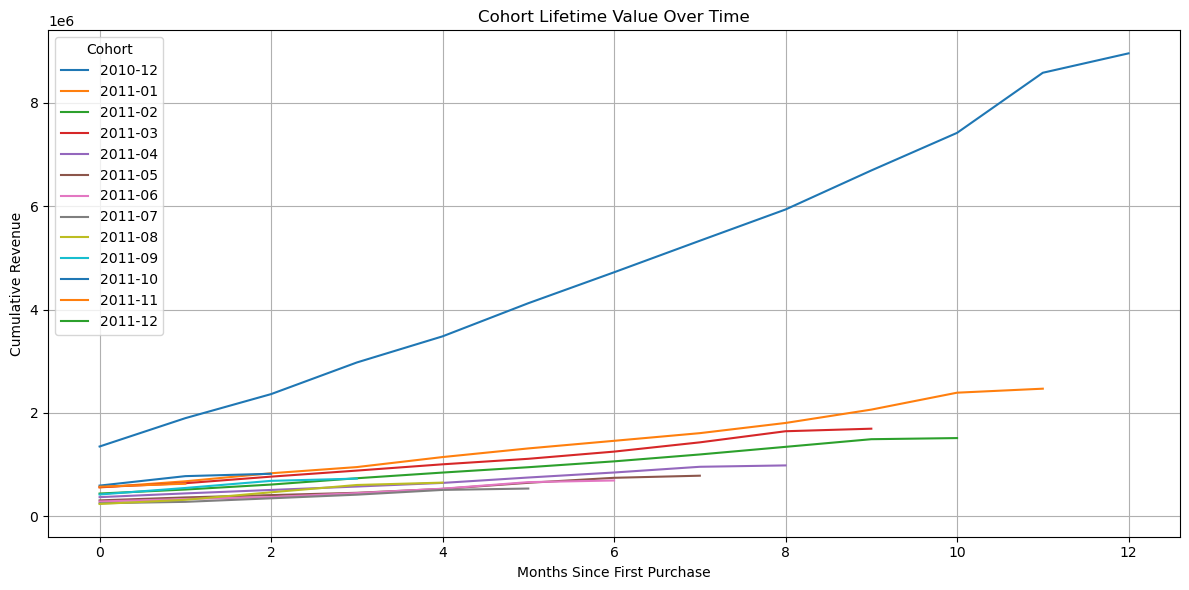

In [26]:
plt.figure(figsize=(12, 6))
for cohort in cohort_cumrev.index:
    plt.plot(cohort_cumrev.columns, cohort_cumrev.loc[cohort], label=str(cohort))
plt.title('Cohort Lifetime Value Over Time')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cumulative Revenue')
plt.legend(title='Cohort')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
cust_purchases = data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cust_purchases['Repeat'] =cust_purchases['InvoiceNo'] > 1

repeat_customers = data[['CustomerID', 'CohortMonth']].drop_duplicates().merge(cust_purchases, on='CustomerID')
repeat_rate = repeat_customers.groupby('CohortMonth')['Repeat'].mean() * 100

## Repeat Purchase Rate

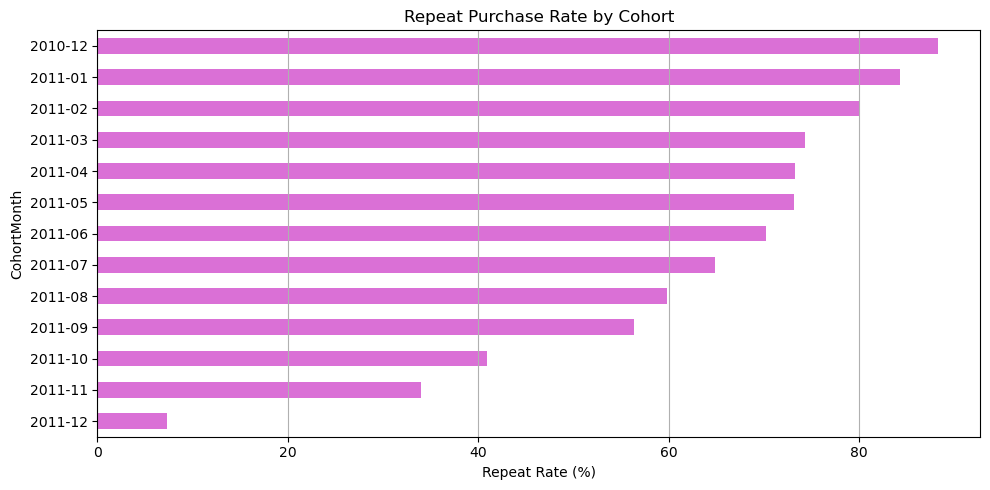

In [28]:
repeat_rate.sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), color='orchid')
plt.title('Repeat Purchase Rate by Cohort')
plt.xlabel('Repeat Rate (%)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

## Repeat Purchase Rate by Cohort - Key Insights

- **Strong early retention:** Customers from older cohorts (like **2010-12 to 2011-02**) show **high repeat rates**, around **80-90%**.
- **Declining trend over time:** Newer cohorts (especially **2011-10 to 2011-12**) show **Sharp drops** in repeat purchase rates.
- **Possible causes:**
    - Changes in marketing strategies
    - Product/experience quality decline
    - Seasonal or economic shifts
- **Actionable Insight:** Investigate what was working well for earlier cohorts and what changed afterward; look into user experience, onboarding, and campaign differences.

The pattern clearly signals **decreasing customer loyalty** in later cohorts; something to act on.

# CHURN DEFINITION & LOGIC

### Goal:

Determine which customers churned; i.e., stopped buying. We need this as our target variable (0 = Active, 1 = Churned).

### Logic:

We define churn as: 'Customer has not purchased in the last 6 months' from the last invoice date in the dataset.

In [29]:
# Snapshot date is the reference point (latest date in data)
snapshot_date = data['InvoiceDate'].max()

# Set churn cutoff (6 months before snapshot date)
churn_cutoff = snapshot_date - pd.DateOffset(months=6)

# Find last purchase date for each customer
last_purchase_date = data.groupby('CustomerID')['InvoiceDate'].max()

# Define churned customers: no purchases in last 6 months
churn_flag = (last_purchase_date < churn_cutoff).astype(int)

In [30]:
churn_flag

CustomerID
12346.0    1
12347.0    0
12348.0    0
12349.0    0
12350.0    1
          ..
18280.0    1
18281.0    0
18282.0    0
18283.0    0
18287.0    0
Name: InvoiceDate, Length: 4372, dtype: int32

# Feature Engineering

### Create RFM Features

These are classic customer value metrics:

Recency: Days since last purchase

Frequency: Number of purchases

Monetary: Total money spent

In [31]:
# Reference date is snapshot_date
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,    # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

## Add Behavioral Features
We enhance RFM with more signals:

In [32]:
# Customer lifetime (in days)
first_purchase = data.groupby('CustomerID')['InvoiceDate'].min()
last_purchase = data.groupby('CustomerID')['InvoiceDate'].max()

rfm['CustomerLifetime'] = (last_purchase - first_purchase).dt.days

# Avg basket size (quantity per invioce)
rfm['AvgBasketSize'] = data.groupby('CustomerID')['Quantity'].mean()

# Total number of transactions
rfm['TotalTransactions'] = data.groupby('CustomerID')['InvoiceNo'].nunique()

In [33]:
# Merge churn label to features
rfm['Churned'] = churn_flag

In [34]:
rfm.head()

,Recency,Frequency,Monetary,CustomerLifetime,AvgBasketSize,TotalTransactions,Churned
CustomerID,,,,,,,
12346.0,325,2,101.89,0,59.500000,2,1
12347.0,1,7,9001.84,365,46.763736,7,0
12348.0,74,4,1707.84,282,49.645161,4,0
12349.0,18,1,3878.88,0,47.041096,1,0
12350.0,309,1,913.75,0,53.941176,1,1


# Modelling

## Data Splitting

In [35]:
from sklearn.model_selection import train_test_split

X = rfm.drop(columns=['Churned'])   # Features
y = rfm['Churned']                  # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training

In [36]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Create 'models' directory
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models')
os.makedirs(models_dir, exist_ok=True)

# Train and save models
rf_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)

# Save models
joblib.dump(rf_clf, os.path.join(models_dir, 'random_forest_model.pkl'))
joblib.dump(xgb_clf, os.path.join(models_dir, 'xgboost_model.pkl'))

print("Models saved successfully!")

Models saved successfully!


## Model Evaluation

In [42]:
# Create 'evaluations' directory
eval_dir = os.path.join(os.path.dirname(os.getcwd()), 'evaluations')
os.makedirs(eval_dir, exist_ok=True)

# Define a function to save confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

def save_evaluation(model_name, y_true, y_pred):
    # Confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(os.path.join(eval_dir, f'{model_name}_ConfusionMatrix.png'))
    plt.close()
    
    # Classification report
    report = classification_report(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.text(0.01, 1.0, report, {'fontsize': 10}, fontproperties='monospace')
    plt.axis('off')
    plt.savefig(os.path.join(eval_dir, f'{model_name}_ClassificationReport.png'), bbox_inches='tight')
    plt.close()
    
    # Print results
    print(f'{model_name} Results:')
    print(report)
    print(confusion_matrix(y_true, y_pred))
    print('-' * 50)
    
# Random Forest evaluation
save_evaluation('RandomForest', y_test, rf_clf.predict(X_test))

# XGBoost evaluation
save_evaluation('XGBoost', y_test, xgb_clf.predict(X_test))

RandomForest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       704
           1       1.00      1.00      1.00       171

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

[[704   0]
 [  0 171]]
--------------------------------------------------
XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       704
           1       1.00      1.00      1.00       171

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

[[704   0]
 [  0 171]]
--------------------------------------------------


In [38]:
!pip install gradio

## create cohort date

Since we are carrying out a Time-based cohort analysis, the cohorts will be grouped according to the dates they made their first purchase

and Retention rate will be calculated by analysis the months they stayed active after their first purchase

In [39]:
#create Invoice month as new feature
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

In [40]:
data["InvoiceDate"]  = data["InvoiceDate"].apply(get_month)
data.tail()

AttributeError: type object 'datetime.datetime' has no attribute 'datetime'

In [ ]:
def get_cohort_date(data):
    """ this function takes in the dataframe
        and returns the cohort date

        variables:
        data = dataframe
        cohort date = the first date they made a purchase
        """

    # assign the minimum date to all unique candidateID, i.e the first day they made a purchase
    data["cohort date"] = data.groupby("CustomerID")["InvoiceDate"].transform("min")

    return data["cohort date"]

In [ ]:
#apply the function created to our dataframe and extract the 2 newly created column

data["cohort date"] = get_cohort_date(data)

In [43]:
data

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,TotalPrice,CohortMonth,InvoiceMonth
0,536365,2010-12-01 08:26:00,17850.0,SC1734,Electronics,65,10.23,Egypt,10.23,2010-12,2010-12
1,536365,2010-12-01 08:26:00,17850.0,SC2088,Furniture,95,19.61,Mali,19.61,2010-12,2010-12
2,536365,2010-12-01 08:26:00,17850.0,SC3463,Books,78,61.49,Mali,61.49,2010-12,2010-12
3,536365,2010-12-01 08:26:00,17850.0,SC6228,Toys,15,24.73,South Africa,24.73,2010-12,2010-12
4,536365,2010-12-01 08:26:00,17850.0,SC2149,Toys,50,38.83,Rwanda,38.83,2010-12,2010-12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,SC5440,Furniture,25,36.53,Mozambique,36.53,2011-08,2011-12
541905,581587,2011-12-09 12:50:00,12680.0,SC3576,Cloths,94,90.65,Tunisia,90.65,2011-08,2011-12
541906,581587,2011-12-09 12:50:00,12680.0,SC5283,Furniture,14,40.07,Somalia,40.07,2011-08,2011-12
541907,581587,2011-12-09 12:50:00,12680.0,SC1099,Cosmetics,45,79.83,Senegal,79.83,2011-08,2011-12


## create cohort index

A cohort index is a numerical representation that measures the time interval in months since a particular group (cohort) made their initial purchase. For example, an index of 4 indicates that this cohort made their first purchase four months ago.

This will be calculated by subtracing the time the customer made first purchase (cohort date) from the recent purchase time (invoice date)

In [ ]:
#create a function that extracts the year and month from the first and last cohort date

def get_year_and_month(data, col):
    """
    This function takes in the dataframe and column,
    and returns the month and year component for that column

    Variables:
    data = dataframe
    col = column
    month = month component
    year = year component"""

    month = data[col].dt.month
    year = data[col].dt.year
    return month, year

In [ ]:
# apply the fucntion on cohort first date column
first_month, first_year = get_year_and_month(data,"cohort date")

In [ ]:
first_month

In [ ]:
# apply the fucntion on cohort latest date column
latest_month, latest_year = get_year_and_month(data,"InvoiceDate")

In [ ]:
latest_month

**CREATE COHORT INDEX**

In [ ]:
# write a function to create cohort index
def create_cohort_index(first_month, first_year, latest_month,latest_year):
    """
    This code creates takes in the first and latest month and year
    and returns the calculated period(in months) the customer has been active

    variables:
    first_month: first month the customer made purchase
    first_year: first year the customer made purchase

    latest_month: recent month the customer made purchase
    latest_year: recent year the customer made purchase

    index: The duration between first and latest purchase (in months)"""

    year_diff = latest_year - first_year
    month_diff = latest_month - first_month
    index = year_diff*12 + month_diff +1 # +1 is added because of customers who have been active for just 1 month
    return index

In [ ]:
data["cohort_index"] = create_cohort_index(first_month, first_year, latest_month, latest_year)

In [ ]:
data

## Create a pivot table

To create a pivot table, first we need to know how many customers made a purchase each month after their first purchase

for example: How many customers from the September cohort made a purchase four months after their initial purchase in September?

### Cohort table

In [ ]:
cohort_info = data.groupby(["cohort date","cohort_index"])["CustomerID"].nunique().reset_index()

In [ ]:
cohort_info.rename(columns = {"CustomerID": "Number of customers"}, inplace = True)

In [ ]:
cohort_info

### Pivot table

In [ ]:
# create a pivot table

cohort_table = cohort_info.pivot(index = "cohort date", columns = ["cohort_index"], values = "Number of customers")

#change index to understandable format
cohort_table.index = cohort_table.index.strftime('%B %Y')
cohort_table

In [ ]:
#visualize our results in heatmap

plt.figure(figsize = (21,10))
sns.heatmap(cohort_table, annot = True, cmap = 'Dark2_r')

**Observe retention rate**

To effeciently observe the customers rentention rate, lets plot the chart in percentage.

In [ ]:
# showing retention rate in percentage
new_cohort_table = cohort_table.divide(cohort_table.iloc[:,0], axis = 0)
new_cohort_table

**Draw heatmap**

In [ ]:
#visualize our results in heatmap

plt.figure(figsize = (21,10))
sns.heatmap(new_cohort_table, annot = True, cmap = 'Dark2_r', fmt = '.0%')

The heatmap above illustrates the customer retention rates for each cohort.

**OBSERVATIONS**

A healthy retention rate for e-commerce platforms is typically considered to be in the range of **20% to 40%.** This means that **20% to 40%** of your customers continue to make purchases from your e-commerce platform after their initial purchase.

- **December 2010 Cohort Outperforms Others:** The fact that the **December 2010** cohort has a retention rate above **30%** is a positive sign. It suggests that this group of customers has remained engaged with your e-commerce platform over time. This could be due to various factors, such as the quality of your products/services, effective marketing, or a strong customer retention strategy.

- **Decline in December 2011:** The observation that all cohorts have low retention rates in December 2011 suggests that there may have been specific challenges or issues affecting customer retention during that time. It's important to investigate what might have caused this decline and whether it's a one-time event or a recurring pattern

- **Variability in Retention Rates:** The range of retention rates, from a **minimum of 8% to a maximum of 50%**, suggests that there is significant variability in how different cohorts of customers are behaving. While 8% is relatively low, 50% is relatively high, considering the standard e-commerce retention rates mentioned earlier.

**RECOMMENDATIONS**

- **Identify Factors Driving High Retention (December 2010):** Analyze what factors have contributed to the high retention rate for the December 2010 cohort. Was there a specific marketing campaign, product improvement, or customer engagement strategy that worked well for this group? Try to replicate successful strategies for other cohorts.

- **Investigate December 2011 Drop:** Investigate why all cohorts have low retention rates on December 2011. It might involve analyzing customer feedback, product quality, customer service, or any changes in your business operations during that time. Identifying and addressing the root causes of this drop is crucial for improving future retention rates.

- **Set Realistic Targets:** While the standard e-commerce retention rate range is 20% to 40%, it's essential to set targets that are specific to your business and its circumstances. Aim to improve retention rates gradually over time based on your historical data and industry benchmarks.

- **Implement Retention Strategies:** Develop and implement retention strategies that are tailored to different cohorts of customers. Personalized marketing, loyalty programs, and targeted communication can help improve retention rates.

- **Continuously Monitor and Adapt:** Retention rates can change over time due to various factors, so it's crucial to continuously monitor them and adapt your strategies accordingly. Regularly analyzing cohort data and customer behavior will help you make informed decisions to improve retention.

In addtion to observing the behaviour of each cohort, we can create a table which shows the average quantity of product bought by each cohort and how it fluctuates.

**Average quantity bought**

In [ ]:
average_quantity = data.groupby(["cohort date", "cohort_index"])["Quantity"].mean().reset_index()
average_quantity["Quantity"] = average_quantity["Quantity"].round(1)

In [ ]:
average_quantity.rename(columns = {"Quantity": "average quantity"}, inplace = True)

In [ ]:
average_quantity

In [ ]:
# create a pivot table

quantity_table = average_quantity.pivot(index = "cohort date", columns = ["cohort_index"], values = "average quantity")

#change index to understandable format
quantity_table.index = quantity_table.index.strftime('%B %Y')
quantity_table

In [ ]:
#visualize our results in heatmap

plt.figure(figsize = (21,10))
sns.heatmap(quantity_table, annot = True, cmap = 'Accent_r')

**Observations**

Although there is significant drop in customer retention after their first month as observed on the previous chart, the average quantity bought is not experiencing much fluctuations. Meaning there is possibiity that a few customers tends to puchase alot of product, therefore maintaining the average value

**Recommendation**

This can serve as a signal to carryout targetted marketing in countries where more quantites are sold in contrast to targeting countries where more customers are acquired.